# Tutorial 1: Integrating adjacent DLPFC slices
This tutorial demonstrates STAligner's ablility to integrate multiple adjacent slices. The slices are sampled from human dorsolateral prefrontal cortex (DLPFC) and the processed data can be downloaded from https://drive.google.com/drive/folders/1pHJy2cB9BKqc3ny9IpvVhiw_8ukJMzPW?usp=share_link.

## Preparation

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
# import ST_utils
# import train_STAligner
import STAligner

# the location of R (used for the mclust clustering)
import os
os.environ['R_HOME'] = '/root/miniconda3/envs/njy1/lib/R'
os.environ['R_USER'] = "/root/miniconda3/envs/njy1/lib/python3.9/site-packages/rpy2"
import rpy2.robjects as robjects
import rpy2.robjects.numpy2ri


import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
import scipy.linalg


import torch

## Load Data

In [3]:
Batch_list = []
adj_list = []
section_ids = ['E9.5_E1S1.MOSTA', 'E10.5_E2S1.MOSTA', 'E11.5_E1S1.MOSTA']
print(section_ids)

['E9.5_E1S1.MOSTA', 'E10.5_E2S1.MOSTA', 'E11.5_E1S1.MOSTA']


In [4]:
for section_id in section_ids:
    print(section_id)
    input_dir = os.path.join('../../../Data/Mouse_Embryo')
    adata = sc.read_h5ad(os.path.join(input_dir, section_id + '.h5ad'))
    adata.var_names_make_unique(join="++")

    # read the annotation
    # Ann_df = pd.read_csv(os.path.join(input_dir, 'manual_annotations.txt'), sep='\t', header=None, index_col=0)
    # Ann_df.columns = ['Ground Truth']
    # Ann_df[Ann_df.isna()] = "unknown"
    # adata.obs['Ground Truth'] = Ann_df.loc[adata.obs_names, 'Ground Truth'].astype('category')
    
    # make spot name unique
    adata.obs_names = [x+'_'+section_id for x in adata.obs_names]
    
    # Constructing the spatial network
    STAligner.Cal_Spatial_Net(adata, rad_cutoff=1.3) # the spatial network are saved in adata.uns[‘adj’]
    # STAligner.Stats_Spatial_Net(adata) # plot the number of spatial neighbors
    
    # Normalization
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=5000)
    adata = adata[:, adata.var['highly_variable']]

    adj_list.append(adata.uns['adj'])
    Batch_list.append(adata)

E9.5_E1S1.MOSTA
------Calculating spatial graph...
The graph contains 23166 edges, 5913 cells.
3.9178 neighbors per cell on average.
E10.5_E2S1.MOSTA
------Calculating spatial graph...
The graph contains 33410 edges, 8494 cells.
3.9334 neighbors per cell on average.
E11.5_E1S1.MOSTA
------Calculating spatial graph...
The graph contains 119204 edges, 30124 cells.
3.9571 neighbors per cell on average.


## Concat the scanpy objects for multiple slices

In [5]:
adata_concat = ad.concat(Batch_list, label="slice_name", keys=section_ids)
# adata_concat.obs['Ground Truth'] = adata_concat.obs['Ground Truth'].astype('category')
adata_concat.obs["batch_name"] = adata_concat.obs["slice_name"].astype('category')
print('adata_concat.shape: ', adata_concat.shape)

adata_concat.shape:  (44531, 1193)


## Concat the spatial network for multiple slices

In [6]:
adj_concat = np.asarray(adj_list[0].todense())
for batch_id in range(1,len(section_ids)):
    adj_concat = scipy.linalg.block_diag(adj_concat, np.asarray(adj_list[batch_id].todense()))
adata_concat.uns['edgeList'] = np.nonzero(adj_concat)

## Running STAligner

In [7]:
# Important parameter:
# "iter_comb" is used to specify the order of integration
# "margin" is used to control the intensity/weight of batch correction
#iter_comb = [(0, 1), (0, 2), (1, 2)] ## Fix slice 2 as reference to align

used_device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
adata_concat = STAligner.train_STAligner(adata_concat, verbose=True, knn_neigh = 100, iter_comb = None,
                                                        margin=2.5,  device=used_device)

STAligner(
  (conv1): GATConv(1193, 512, heads=1)
  (conv2): GATConv(512, 30, heads=1)
  (conv3): GATConv(30, 512, heads=1)
  (conv4): GATConv(512, 1193, heads=1)
)
Pretrain with STAGATE...


100%|██████████| 500/500 [00:13<00:00, 36.51it/s]


Train with STAligner...


  0%|          | 0/500 [00:00<?, ?it/s]

Update spot triplets at epoch 500


...

 59%|█████▉    | 297/500 [01:15<00:06, 33.57it/s]

Update spot triplets at epoch 800


 79%|███████▉  | 397/500 [01:44<00:03, 33.26it/s]

Update spot triplets at epoch 900


100%|██████████| 500/500 [02:15<00:00,  3.69it/s]


## Clustering

In [8]:
STAligner.ST_utils.mclust_R(adata_concat, num_cluster=20, used_obsm='STAligner')

# louvain
# sc.pp.neighbors(adata_concat, use_rep='STAligner', random_state=666)
# sc.tl.louvain(adata_concat, random_state=666, key_added="louvain", resolution=0.35)

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


AnnData object with n_obs × n_vars = 44531 × 1193
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'annotation', 'Regulon - Alx1', 'Regulon - Alx3', 'Regulon - Alx4', 'Regulon - Barhl1', 'Regulon - Bcl3', 'Regulon - Bclaf1', 'Regulon - Bmyc', 'Regulon - Brf2', 'Regulon - Bsx', 'Regulon - Cdx2', 'Regulon - Cebpa', 'Regulon - Clock', 'Regulon - Creb3l1', 'Regulon - Crem', 'Regulon - Ctcf', 'Regulon - Cux1', 'Regulon - Dbx1', 'Regulon - Dbx2', 'Regulon - Dlx1', 'Regulon - Dlx2', 'Regulon - Dlx5', 'Regulon - Dlx6', 'Regulon - E2f1', 'Regulon - E2f2', 'Regulon - E2f3', 'Regulon - E2f4', 'Regulon - E2f6', 'Regulon - Egr3', 'Regulon - Elk1', 'Regulon - Elk3', 'Regulon - Emx1', 'Regulon - Emx2', 'Regulon - Esrra', 'Regulon - Esrrg', 'Regulon - Ets1', 'Regulon - Ets2', 'Regulon - Etv2', 'Regulon - Evx1', 'Regulon - Evx2', 'Regulon - Ezh2', 'Regulon - Fli1', 'Regulon - Foxa1', 'Regulon - Foxa2', 'Regulon - Foxa3', 'Regulon - Foxc2', 'Regulon - Foxd3'

In [9]:
# sc.tl.umap(adata_concat, random_state=666)
# colors_default = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
#                   '#8c564b', '#e377c2', '#bcbd22', '#17becf', '#aec7e8',
#                   '#ffbb78', '#98df8a', '#ff9896', '#bec1d4', '#bb7784',
#                   '#0000ff']
# adata_concat.uns['louvain_colors'] = [colors_default[0:][i] for i in np.sort(adata_concat.obs['mclust'].unique().astype('int'))]
# 
# import matplotlib.pyplot as plt
# plt.rcParams['font.sans-serif'] = "Arial"
# plt.rcParams["figure.figsize"] = (2, 2)
# plt.rcParams['font.size'] = 10
# 
# sc.pl.umap(adata_concat, color=['batch_name', 'mclust'], ncols=2, wspace=1, show=True)

In [10]:
# for ss in range(len(section_ids)):
#     Batch_list[ss].obs['louvain'] = adata_concat[adata_concat.obs['batch_name'] == section_ids[ss]].obs['mclust'].values
#     Batch_list[ss].uns['louvain_colors'] = [colors_default[0:][i] for i in np.sort(adata_concat[adata_concat.obs['batch_name'] == 
#                                                                             section_ids[ss]].obs['mclust'].unique().astype('int'))]       
# 
# import matplotlib.pyplot as plt
# spot_size = 1
# title_size = 10
# fig, ax = plt.subplots(1, len(section_ids), figsize=(len(section_ids)*3, 3), gridspec_kw={'wspace':1, 'hspace': 0.1})    
# for ss in range(len(section_ids)-1):
#     _sc_0 = sc.pl.spatial(Batch_list[ss], img_key=None, color=['mclust'], title=['mclust'], size=1.5, legend_fontsize=8, 
#                   show=False, frameon=False, ax=ax[ss], spot_size=spot_size)
#     _sc_0[0].set_title(section_ids[ss], size=title_size)
# _sc_0 = sc.pl.spatial(Batch_list[-1], img_key=None, color=['mclust'], title=['mclust'], size=1.5, legend_fontsize=8, 
#               show=False, frameon=False, ax=ax[-1], spot_size=spot_size)
# _sc_0[0].set_title(section_ids[-1], size=title_size)
# plt.show()

In [11]:
#adata_concat.write('adata_STAligner_MOE.h5ad')

In [5]:
#adata_concat = sc.read_h5ad('adata_STAligner_MOE.h5ad')

In [6]:
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.metrics import normalized_mutual_info_score as nmi_score
from sklearn.metrics import adjusted_mutual_info_score as ami_score
from sklearn.metrics import homogeneity_score as hom_score
from sklearn.metrics import completeness_score as com_score

In [7]:
sub_adata = adata_concat[~pd.isnull(adata_concat.obs['annotation'])]
ARI = ari_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
print(f"total ARI:{ARI}")
for name in section_ids:
    sub_adata_tmp = sub_adata[sub_adata.obs['batch_name'] == name]
    ARI = ari_score(sub_adata_tmp.obs['annotation'], sub_adata_tmp.obs['mclust'])
    print(f"{name} ARI:{ARI}")

total ARI:0.23875983103069204
E9.5_E1S1.MOSTA ARI:0.2917527598910609
E10.5_E2S1.MOSTA ARI:0.24722989743257898
E11.5_E1S1.MOSTA ARI:0.3125548629748729


In [8]:
sub_adata = adata_concat[~pd.isnull(adata_concat.obs['annotation'])]
NMI = nmi_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
print(f"total NMI:{NMI}")
for name in section_ids:
    sub_adata_tmp = sub_adata[sub_adata.obs['batch_name'] == name]
    NMI = nmi_score(sub_adata_tmp.obs['annotation'], sub_adata_tmp.obs['mclust'])
    print(f"{name} NMI:{NMI}")

total NMI:0.4798876224635781
E9.5_E1S1.MOSTA NMI:0.46829449448036736
E10.5_E2S1.MOSTA NMI:0.49371163696307757
E11.5_E1S1.MOSTA NMI:0.5575964695125859


In [9]:
sub_adata = adata_concat[~pd.isnull(adata_concat.obs['annotation'])]
HOM = hom_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
print(f"total NMI:{HOM}")
for name in section_ids:
    sub_adata_tmp = sub_adata[sub_adata.obs['batch_name'] == name]
    HOM = hom_score(sub_adata_tmp.obs['annotation'], sub_adata_tmp.obs['mclust'])
    print(f"{name} HOM:{HOM}")

total NMI:0.4760195631163446
E9.5_E1S1.MOSTA HOM:0.49679255699791874
E10.5_E2S1.MOSTA HOM:0.49005718364206724
E11.5_E1S1.MOSTA HOM:0.5766964613753437


In [10]:
import scib

sc.pp.neighbors(adata_concat, use_rep="STAligner")
scib.me.graph_connectivity(adata_concat, label_key="annotation")

/root/miniconda3/envs/njy1/lib/python3.9/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
/root/miniconda3/envs/njy1/lib/python3.9/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/root/miniconda3/envs/njy1/lib/python3.9/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/root/miniconda3/envs/njy1/lib/python3.9/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future v

0.9430016164625443

/root/miniconda3/envs/njy1/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


/root/miniconda3/envs/njy1/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/root/miniconda3/envs/njy1/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


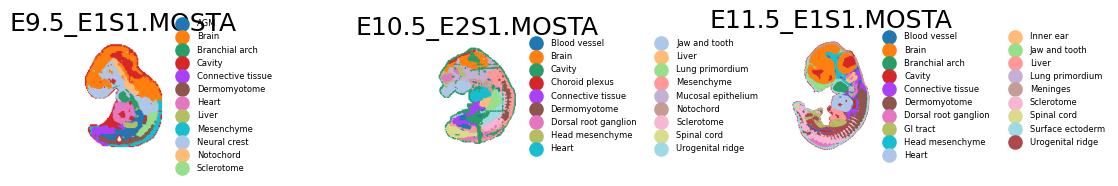

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 12))
k = 1
spot_size = 2
for slice_id, slice_name in enumerate(section_ids):
    adata_tmp = adata_concat[adata_concat.obs['batch_name'] == section_ids[slice_id]]
    ax = plt.subplot(2, 4, k)
    # sc.pl.embedding(adata_tmp, basis='spatial', color='annotation', s=45, ax=ax, show=False, legend_loc=False)
    sc.pl.spatial(adata_tmp, img_key=None, color=['annotation'], title=[''],
                  legend_loc='right margin', legend_fontsize=6, show=False, ax=ax, frameon=False,
                  spot_size=spot_size)
    plt.title(f'{slice_name}')
    k += 1
plt.tight_layout()

/root/miniconda3/envs/njy1/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


/root/miniconda3/envs/njy1/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/root/miniconda3/envs/njy1/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


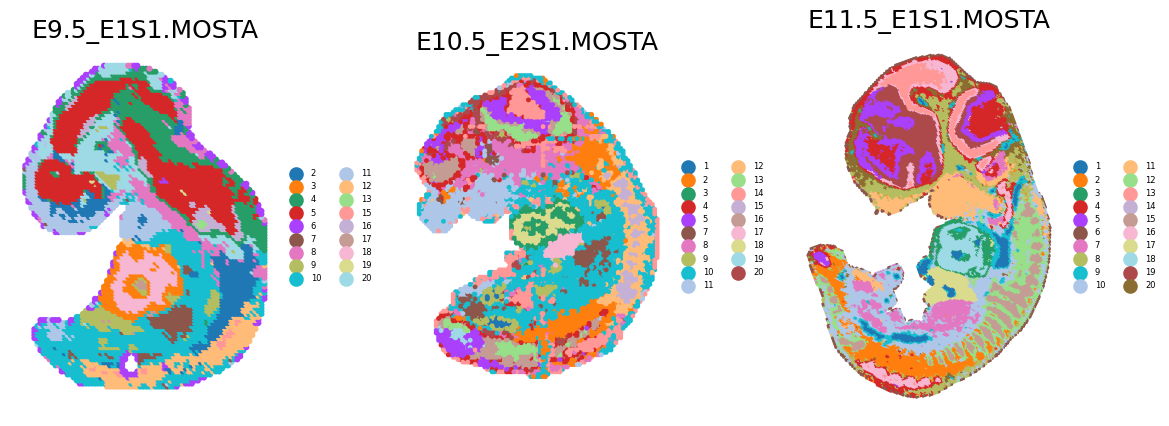

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
k = 1
spot_size = 2
for slice_id, slice_name in enumerate(section_ids):
    adata_tmp = adata_concat[adata_concat.obs['batch_name'] == section_ids[slice_id]]
    ax = plt.subplot(2, 4, k)
    # sc.pl.embedding(adata_tmp, basis='spatial', color='annotation', s=45, ax=ax, show=False, legend_loc=False)
    sc.pl.spatial(adata_tmp, img_key=None, color=['mclust'], title=[''],
                  legend_loc="right margin", legend_fontsize=6, show=False, ax=ax, frameon=False,
                  spot_size=spot_size)
    plt.title(f'{slice_name}')
    k += 1
plt.tight_layout()